## Evaluate All Methods with Solutions

### Manage Packages

In [14]:
# Import all required packages
import ray
ray.shutdown()
import pandas as pd                   # For data manipulation and analysis
import io
import gymnasium as gym
import numpy as np
import os
import pickle
import copy
import random
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.ticker as ticker
import warnings
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
import torch
import networkx as nx
from tqdm import tqdm
from scipy.stats import ttest_ind
import seaborn as sns
from collections import defaultdict

# Import custom zero counting function
def count_zeros(arr):
    return np.count_nonzero(arr < 0.00001)

# Import custom environment .py file
import env_TA as ce

### Input Parameters

In [20]:
##### User Determined Settings
graphName = "G5x5"  # Graph nodes and edges to use
env_params = {'deterministic_agent': False,
              'multiple_interdiction_attempts': False,
              'attacker_strategy': 'divert',  # canalize   isolate   divert  zero_sum
              'training_budget_range': (3, 25),  #G5x5: zero_sum/isolate: (5,15), canalize/divert: (12,24) G10x10: zero_sum/isolate: (15,30), canalize/divert: (20,40)   #UKR: zero_sum/isolate: (10,20), canalize/divert: (18,30)
              'max_path_length': 2,  #G5x5: 2,  G10x10: 3, UKR: 4
              'sample_size': None,
              'penalty_value': -0.01,
             }

solution_name = 'v04_27_bi'

method_type = 'RL'  # 'RL' 'Alternate_Solution' 'Max-Flow_Heuristic', 'Min-Cut_Heuristic' or 'Baycik'

#'RL' Settings
if method_type == 'RL':
    model_name = "G5x5_S_MaskablePPO_divert_B_v04_27"
    model_timesteps = 6000000#None # Set a number or  None
    RL_classify = False
    RL_classify_budget_range = False # Flag to classify over budget range
    RL_classify_budgets = None#[5, 10, 15, 20, 25] # List of specific budgets to test if range flag is True. If None, uses training_budget_range

elif method_type == 'Alternate_Solution': #'Alternate_Solution' Settings
    alt_solution_name = 'v03_20_bi'
    model_name = f"Solution {alt_solution_name}"

elif method_type == 'Max-Flow_Heuristic':
    model_name = "Max-Flow_Heuristic Solution"

elif method_type == 'Min-Cut_Heuristic':
    model_name = "Min-Cut_Heuristic Solution"

elif method_type == 'Baycik':
    model_name = "Baycik Solution"
    baycik_training_solution_name = solution_name
    baycik_training_indices = (500, 3500) #3500) # Start and end index for training episodes

### Create Environment, Agent, and Load Optimal Solutions

In [21]:
## Create Environment
# Create nodes and edges
node_filename = f"{graphName}_Nodes.csv"  # Dynamically include graphName
edge_filename = f"{graphName}_Edges.csv"  # Dynamically include graphName

nodes, edges = ce.create_nodes_edges(node_filename, edge_filename)

# Load Environment
env = ce.CustomEnv(nodes, edges, **env_params)

# Get the current recovering directory
current_dir = os.getcwd()

# Determine Model Path if using RL
if method_type == 'RL': 
    models_dir = os.path.join(current_dir, '..', 'Trained_RL_Models')

    # LOAD Previous saved model
    if model_timesteps == None:
        model_path = f"{models_dir}/{model_name}/best_model"
    else:    model_path = f"{models_dir}/{model_name}/{model_name}_{model_timesteps}_steps"
    data = np.load(f"{models_dir}/{model_name}/evaluations.npz")

    # Load the model
    if "MaskablePPO" in model_name:
        from sb3_contrib import MaskablePPO
        agent=MaskablePPO.load(model_path,)

## Load Optimal Solutions for Comparison
if env_params['multiple_interdiction_attempts'] == True:
    MI_letter = 'M'
else:
    MI_letter = 'B'

# IMPORTANT CHANGE: Skip loading optimal solution if RL_classify is True
if not (method_type == 'RL' and RL_classify):
    #load and Read Pickle File of Solutions
    # Use the same path and filename as in your saving code
    save_filename = f"{graphName}_{env_params['attacker_strategy']}_{MI_letter}_solution_{solution_name}.pkl"   

    save_path = os.path.join(current_dir, '..', 'Solutions', save_filename)

    # Open the pickle file in binary read mode and load the data
    with open(save_path, "rb") as f:
        results = pickle.load(f)

    # Now you can access the saved data
    print("Solution Stats")
    print("Episodes completed:", results["last_episode"] + 1)
    print("Mean Objective values:", np.mean(results["optimal_obj_vals"][0:500]))
    #print("Interdiction sets:", results["all_optimal_interdiction_edges"])
    print("Mean Solution times:", np.mean(results["optimal_solution_times"][0:500]))

    optimal_obj_vals = results["optimal_obj_vals"]
    all_optimal_interdiction_edges = results["all_optimal_interdiction_edges"]
    optimal_solution_times = results["optimal_solution_times"]
    all_states = results['states']
else:
    print("Skipping Optimal Solution Load for RL Classification")
    optimal_obj_vals = None
    all_optimal_interdiction_edges = None
    optimal_solution_times = None
    all_states = None

if method_type == 'Alternate_Solution':
    alt_save_filename = f"{graphName}_{env_params['attacker_strategy']}_{MI_letter}_solution_{alt_solution_name}.pkl"   

    alt_save_path = os.path.join(current_dir, '..', 'Solutions', alt_save_filename)

    # Open the pickle file in binary read mode and load the data
    with open(alt_save_path, "rb") as f:
        alt_results = pickle.load(f)

    # Now you can access the saved data
    print()
    print("Alternate Solution Stats")
    print("Episodes completed:", alt_results["last_episode"] + 1)
    print("Mean Objective values:", np.mean(alt_results["optimal_obj_vals"][0:500]))
    #print("Interdiction sets:", alt_results["all_optimal_interdiction_edges"])
    print("Mean Solution times:", np.mean(alt_results["optimal_solution_times"][0:500]))

    alt_optimal_obj_vals = alt_results["optimal_obj_vals"]
    alt_all_optimal_interdiction_edges = alt_results["all_optimal_interdiction_edges"]
    alt_optimal_solution_times = alt_results["optimal_solution_times"]
    alt_all_states = alt_results['states']

# Train Baycik Model if selected
if method_type == 'Baycik':
    baycik_training_filename = f"{graphName}_{env_params['attacker_strategy']}_{MI_letter}_solution_{baycik_training_solution_name}.pkl"
    baycik_training_path = os.path.join(current_dir, '..', 'Solutions', baycik_training_filename)
    
    # Reset env to ensure state is initialized before training
    env.reset()
    
    # Train the model
    print(f"Training Baycik model on {baycik_training_filename} (Indices: {baycik_training_indices})...")
    baycik_model = env.train_baycik_model(baycik_training_path, 
                                          start_index=baycik_training_indices[0], 
                                          end_index=baycik_training_indices[1])
    print("Baycik Model Trained.")

Solution Stats
Episodes completed: 276
Mean Objective values: 17.866465228289382
Mean Solution times: 271.5506041890248


/state/partition1/llgrid/pkg/anaconda/python-ML-2025a/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


#### Secondary Functions

In [12]:
#Compare Solutions
start = 0
end = start+1
end = 50
print('Optimal Objs: ',optimal_obj_vals[start:end])
print('Optimal Times: ', optimal_solution_times[start:end])
print('Optimal Actions: ',all_optimal_interdiction_edges[start:end])

if method_type == 'Alternate_Solution':
    print('Alt Optimal Objs: ', alt_optimal_obj_vals[start:end])
    print('Alt Optimal Times: ', alt_optimal_solution_times[start:end])
    print('Alt Optimal Actions: ',alt_all_optimal_interdiction_edges[start:end])

Optimal Objs:  [16.18843901 11.82908782  8.68743652 24.7805482  24.76854904 27.52351255
 29.91467862 13.24317457 20.89845482 20.36380691 25.33453748 13.33746658
 28.48706957 37.99921148 17.56533867 51.1182643  18.81493538 26.6675191
 22.75171855 31.60037032 15.55077308 22.58725114 30.2064305  16.70368002
 17.89115507 12.10005345 34.24078061 34.0895591  19.52735808 47.62874749
 41.79297221 15.77824276 23.77346533 37.94121488 18.89900959 29.57674887
 32.5811107  15.88681865 28.76100694 36.98966784  6.22935671 21.73539265
 40.36528472 28.64371979 20.81343478 30.11759483 24.69848431 31.12879794
  6.87570524 34.67284362]
Optimal Times:  [123.08242479804903, 105.31363775895443, 22.87479380995501, 10.254474529996514, 371.8053816079628, 304.6474465789506, 41.03808565100189, 121.89028250798583, 63.669676919002086, 181.72954666404985, 1109.920408340986, 9.994166472926736, 16.407027586945333, 222.1970988169778, 293.1840529240435, 101.33094175392762, 43.04606436297763, 290.9894515410997, 361.53866

In [16]:
#Determine the budget range of a solution
min = 30
max = 0
for i in range(0,200):
    val = all_states[i][0]['budget'][0]
    if val < min:
        min = val
    if val > max:
        max = val
print(min)
print(max)
#alt_all_states[0][0]['budget']

12
24


## Analysis

### Code

In [4]:
#Training Analysis Plot
def plot_training_curve(data, model_name, figsize=(6, 3.4), xlim=(0, 5000000), ylim=(0, 5), 
                       xlabel='Training Step', ylabel='Mean Step Reward', 
                       title=None, x_tick_interval=1000000, show_legend=True):
    """
    Plot training curve with consistent formatting for reinforcement learning results
    
    Parameters:
    - data: Dictionary containing 'timesteps' and 'results' keys
    - model_name: String label for the plotted line
    - figsize: Tuple for figure size (width, height)
    - xlim: Tuple for x-axis limits (min, max)
    - ylim: Tuple for y-axis limits (min, max)
    - xlabel: String for x-axis label
    - ylabel: String for y-axis label
    - title: String for plot title (optional)
    - x_tick_interval: Integer for x-axis tick spacing
    - show_legend: Boolean to show/hide legend
    """
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import numpy as np
    import seaborn as sns
    
    plt.figure(figsize=figsize)
    
    # Set consistent formatting
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 14,
        'axes.titlesize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
    })
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.family'] = 'STIXGeneral'
    
    # Extract data and compute mean rewards
    timesteps = data['timesteps']
    results = data['results']
    mean_rewards = np.mean(results, axis=1)
    
    # Plot the training curve
    plt.plot(timesteps, mean_rewards, label=model_name)
    
    # Set labels and title
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if title:
        plt.title(title)
    
    # Show legend if requested
    if show_legend:
        plt.legend()
    
    # Set axis limits
    plt.xlim(xlim[0], xlim[1])
    plt.ylim(ylim[0], ylim[1])
    
    # Set x-axis ticks at specified intervals
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(x_tick_interval))
    
    # Format x-axis tick labels with commas
    def format_func(value, tick_number):
        return f"{value:,.0f}"
    
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    
    # Apply clean styling
    sns.despine()
    plt.show()

import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

#Optimal Interdicted Edge Histogram
def plot_edge_histogram_from_lists(edge_lists, title="Interdicted Edge Frequency Histogram", figsize=(12, 6), 
                                 combine_all=True, show_individual=False):
    """
    Create a histogram from a list of lists of edges showing frequency of occurrence.
    
    Parameters:
    edge_lists: List of lists, where each inner list contains edge tuples
                e.g., [[(1,2), (2,3)], [(1,2), (3,4)], [(2,3), (1,2)]]
    title: Title for the plot
    figsize: Figure size (width, height)
    combine_all: If True, combines all edges from all lists into one histogram
    show_individual: If True, shows separate histograms for each list
    
    Returns:
    Dictionary with frequency data
    """
    
    if combine_all:
        # Flatten all edge lists into one big list
        all_edges = []
        for edge_list in edge_lists:
            all_edges.extend(edge_list)
        
        # Count occurrences of each edge across all lists
        edge_counts = Counter(all_edges)
        
        # Sort edges for consistent ordering
        sorted_edges = sorted(edge_counts.keys())
        counts = [edge_counts[edge] for edge in sorted_edges]
        edge_labels = [f"({edge[0]},{edge[1]})" for edge in sorted_edges]
        
        # Create the bar plot
        plt.figure(figsize=figsize)
        bars = plt.bar(range(len(edge_labels)), counts, alpha=0.7, color='steelblue')
        
        # Customize the plot
        plt.xlabel('Edges')
        plt.ylabel('Total Frequency Across 1,000 Episodes')
        plt.title(f"{title}")
        plt.xticks(range(len(edge_labels)), edge_labels, rotation=45, ha='right')
        
        # Add value labels on top of bars
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    str(count), ha='center', va='bottom')
        
        plt.tight_layout()
        plt.grid(axis='y', alpha=0.3)
        plt.show()
        
        return {"combined": edge_counts, "total_edges": len(all_edges), "num_lists": len(edge_lists)}

#Heatmap of Interdicted Edges on Graph
def plot_graph_with_node_types(nodes, edges, interdiction_counts, 
                               title="Network Graph with Node Types and Interdiction Counts", 
                               figsize=(12, 6), colormap='Reds'):
    """
    Enhanced plotting function that colors nodes by type and edges by interdiction counts
    
    Parameters:
    - nodes: Dictionary of Node objects
    - edges: Dictionary of Edge objects  
    - interdiction_counts: Dictionary with edge keys and count values
    - title: Graph title
    - figsize: Figure size
    - colormap: Matplotlib colormap for edge coloring ('Reds', 'Blues', 'viridis', etc.)
    """
    import matplotlib.cm as cm
    from matplotlib.colors import Normalize
    
    # Create NetworkX graph
    G = nx.DiGraph()
    
    # Add nodes and edges
    for node_id, node_obj in nodes.items():
        G.add_node(node_id, 
                   pos=(node_obj.xpos, node_obj.ypos),
                   node_type=node_obj.node_type)
    
    for edge_id, edge_obj in edges.items():
        origin, destination = edge_id
        # Get interdiction count for this edge (default to 0 if not found)
        count = interdiction_counts.get(edge_id, 0)
        G.add_edge(origin, destination, 
                   interdictable=edge_obj.interdictable,
                   interdiction_count=count)
    
    plt.figure(figsize=figsize)
    pos = nx.get_node_attributes(G, 'pos')
    
    # Get unique node types and assign colors
    node_types = nx.get_node_attributes(G, 'node_type')
    # Define the order you want in the legend
    desired_order = ['source', 'intermediate', 'sink']
    
    # Filter to only include types that actually exist in your graph
    available_types = set(node_types.values())
    ordered_types = [node_type for node_type in desired_order if node_type in available_types]
    
    # Assign colors to node types in the specified order (swapped source and intermediate)
    colors = plt.cm.Set3(np.linspace(0, 1, len(ordered_types)))
    # Create color mapping with source and intermediate colors swapped
    if len(ordered_types) >= 2:
        # Swap colors for source and intermediate
        color_list = list(colors)
        if 'source' in ordered_types and 'intermediate' in ordered_types:
            source_idx = ordered_types.index('source')
            intermediate_idx = ordered_types.index('intermediate')
            color_list[source_idx], color_list[intermediate_idx] = color_list[intermediate_idx], color_list[source_idx]
        type_color_map = dict(zip(ordered_types, color_list))
    else:
        type_color_map = dict(zip(ordered_types, colors))
    
    # Draw nodes colored by type in the specified order
    for node_type in ordered_types:
        node_list = [node for node, ntype in node_types.items() if ntype == node_type]
        nx.draw_networkx_nodes(G, pos,
                              nodelist=node_list,
                              node_color=[type_color_map[node_type]],
                              node_size=500,
                              alpha=0.9,
                              label=f'{node_type.title()}')  # Capitalize first letter
    
    # Prepare edge coloring based on interdiction counts
    interdictable_edges = [(u, v) for u, v, d in G.edges(data=True) if d['interdictable']]
    non_interdictable_edges = [(u, v) for u, v, d in G.edges(data=True) if not d['interdictable']]
    
    # Get interdiction counts for interdictable edges
    if interdictable_edges:
        edge_counts = [G[u][v]['interdiction_count'] for u, v in interdictable_edges]
        
        # Handle case where all counts are zero
        if max(edge_counts) > 0:
            # Normalize counts for colormap
            norm = Normalize(vmin=0, vmax=max(edge_counts))
            cmap = mpl.colormaps[colormap]  #cm.get_cmap(colormap)  
            edge_colors = [cmap(norm(count)) for count in edge_counts]
            
            # Draw interdictable edges with color based on counts
            nx.draw_networkx_edges(G, pos, 
                                  edgelist=interdictable_edges,
                                  edge_color=edge_colors,
                                  width=5,
                                  alpha=0.8,
                                  arrows=False)
            
            # Add colorbar for edge counts with decreased horizontal spacing
            sm = cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8, pad=0.02)  # Changed pad from 0.1 to 0.02
            cbar.set_label('Interdiction Count', rotation=270, labelpad=15)
            
        else:
            # All counts are zero, draw in default color
            nx.draw_networkx_edges(G, pos, 
                                  edgelist=interdictable_edges,
                                  edge_color='lightcoral',
                                  width=5,
                                  alpha=0.7,
                                  arrows=True)
    
    # Draw non-interdictable edges in gray
    if non_interdictable_edges:
        nx.draw_networkx_edges(G, pos, 
                              edgelist=non_interdictable_edges,
                              edge_color='gray',
                              width=5,
                              alpha=0.5,
                              arrows=False)
    
    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    
    # Create legend with increased line spacing
    legend = plt.legend(scatterpoints=1, loc='upper left', 
                        labelspacing=1.5)    
    legend.set_frame_on(False)  # Enable legend frame
    legend.get_frame().set_facecolor('white')  # Set background color
    legend.get_frame().set_alpha(0.9)  # Set transparency
    
    # Increase spacing between legend entries
    for i, text in enumerate(legend.get_texts()):
        text.set_verticalalignment('center')
    
    # Adjust legend spacing by modifying the legend properties
    plt.setp(legend.get_texts(), fontsize=12)  # Optional: adjust font size   
    plt.tight_layout()
    
    # Print statistics
    total_interdictions = sum(interdiction_counts.values())
    max_count = max(interdiction_counts.values()) if interdiction_counts else 0
    print(f"\nInterdiction Statistics:")
    print(f"- Total interdictions across all edges: {total_interdictions}")
    print(f"- Maximum interdictions on single edge: {max_count}")
    print(f"- Number of edges with interdictions: {sum(1 for count in interdiction_counts.values() if count > 0)}")
    
    plt.show()
    return G

### Plots

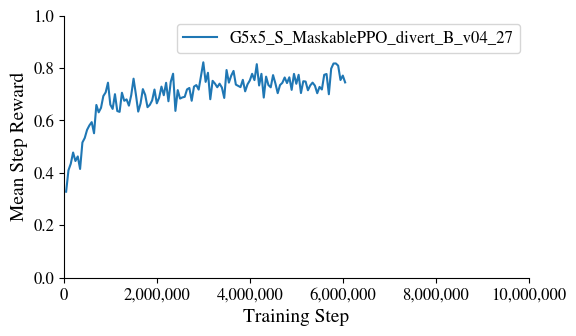

In [19]:
plot_training_curve(data, model_name, xlim=(0, 10000000), ylim=(0, 1), x_tick_interval=2000000)

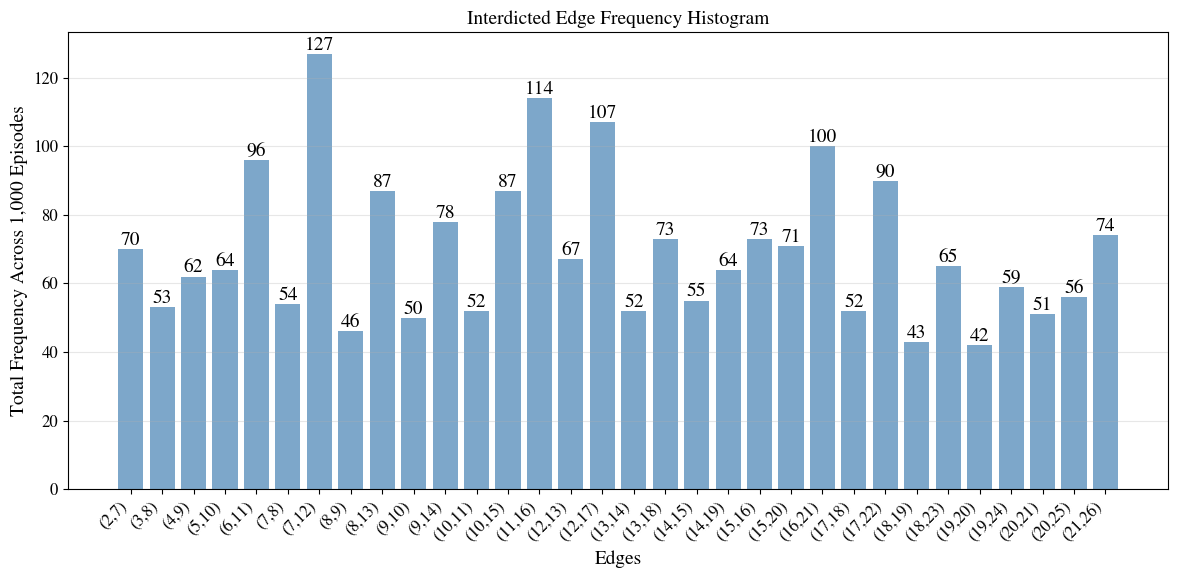

In [6]:
your_edge_lists = all_optimal_interdiction_edges
plots = plot_edge_histogram_from_lists(your_edge_lists)
interdiction_counts=plots['combined']


Interdiction Statistics:
- Total interdictions across all edges: 2234
- Maximum interdictions on single edge: 127
- Number of edges with interdictions: 32


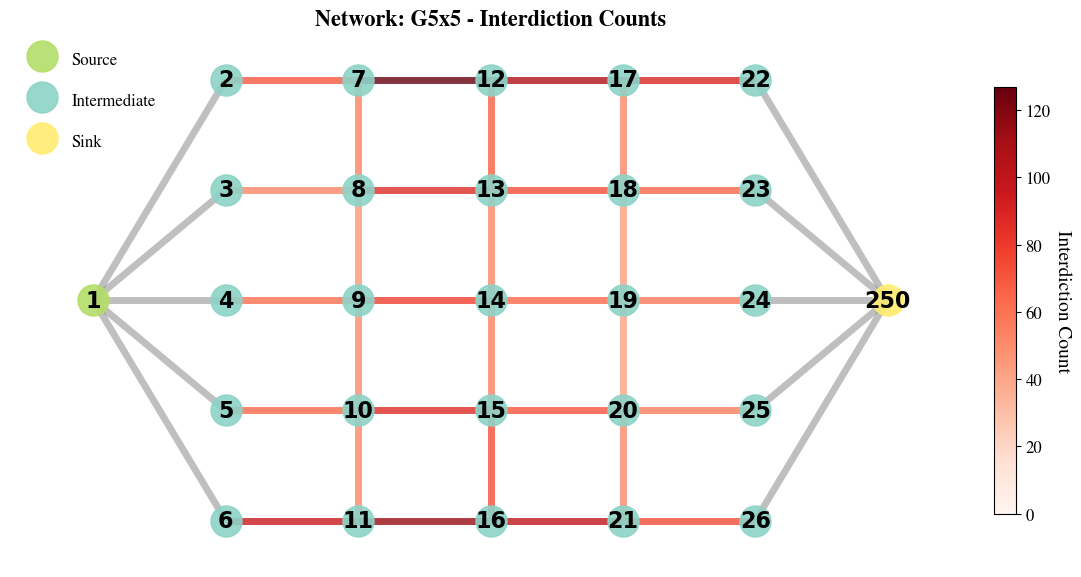

In [27]:
if __name__ == "__main__":
    # Plot with edge colors based on interdiction counts
    G = plot_graph_with_node_types(nodes, edges, interdiction_counts, 
                                   title=f"Network: {graphName} - Interdiction Counts")

### Evaluate Performance Against Optimal Solution

In [22]:
num_of_scenarios = 276
# Pre-compute constants outside the loop
interdictable_edges_list = list(env.both_edges)

# Initialize arrays to store results
reference_objs =  np.zeros(num_of_scenarios)
agent_best_rewards = np.zeros(num_of_scenarios)
start_flows = np.zeros(num_of_scenarios)
end_flows = np.zeros(num_of_scenarios)
budgets = np.zeros(num_of_scenarios)

# Pre-size list for agent actions instead of appending
all_agent_actions = [None] * num_of_scenarios
agent_solution_times = np.zeros(num_of_scenarios)
uniterdicted_flow = np.zeros(num_of_scenarios)
max_flow_left = np.zeros(num_of_scenarios)

if method_type == 'RL': 
    agent.policy.eval()

# Variables for tracking RL_classify stats
total_rl_actions_all = 0
overlap_min_cut = 0
overlap_max_flow = 0
overlap_adj_min_cut = 0
overlap_adj_max_flow = 0
overlap_upstream = 0
overlap_downstream = 0
overlap_other = 0

# Arrays for tracking RL_classify stats per episode
rl_actions_count = np.zeros(num_of_scenarios)
overlap_min_cut_count = np.zeros(num_of_scenarios)
overlap_max_flow_count = np.zeros(num_of_scenarios)
overlap_adj_min_cut_count = np.zeros(num_of_scenarios)
overlap_adj_max_flow_count = np.zeros(num_of_scenarios)
overlap_upstream_count = np.zeros(num_of_scenarios)
overlap_downstream_count = np.zeros(num_of_scenarios)
overlap_other_count = np.zeros(num_of_scenarios)

if method_type == 'RL' and RL_classify and RL_classify_budget_range:
    if 'RL_classify_budgets' in locals() and RL_classify_budgets is not None:
        budget_values = RL_classify_budgets
    else:
        budget_start, budget_end = env_params['training_budget_range']
        budget_values = range(budget_start, budget_end + 1)
    
    # Structure to hold aggregated results per budget
    budget_results = defaultdict(lambda: {
        'total_actions': 0,
        'min_cut': 0,
        'adj_min_cut': 0,
        #'max_flow': 0, 
        'adj_max_flow': 0,
        'upstream': 0,
        'downstream': 0,
        'other': 0
    })

for episode in tqdm(range(num_of_scenarios)):
    
    if method_type == 'RL' and RL_classify:
        # Randomly generate the environment if classifying RL behavior (don't load solution)
        obs, _ = env.reset()
        base_env_state = copy.deepcopy(env.state) # Keep a base state
    else:
        env_state = copy.deepcopy(all_states[episode][0])
        # Pass a deepcopy to avoid the environment mutating the stored env_state
        obs, _ = env.load_network_from_state(episode, copy.deepcopy(env_state))
        # Keep base state for consistency or future use
        base_env_state = copy.deepcopy(env_state)

    if method_type == 'RL' and RL_classify and RL_classify_budget_range:
        current_episode_budgets = budget_values
    else:
        current_episode_budgets = [env.state['budget'][0]]
    
    for budget_val in current_episode_budgets:
        # Determine the state to use for this iteration
        if method_type == 'RL' and RL_classify and RL_classify_budget_range:
             # Force specific budget on the environment
             current_iter_state = copy.deepcopy(base_env_state)
             current_iter_state['budget'] = np.array([budget_val], dtype=int)
             # Use a COPY to prevent the heuristic from dirtying current_iter_state
             obs, _ = env.load_network_from_state(episode, copy.deepcopy(current_iter_state))
        elif method_type == 'RL' and RL_classify:
             # Use the clean random state generated at start of episode
             current_iter_state = copy.deepcopy(base_env_state)
             # Use a COPY to prevent the heuristic from dirtying current_iter_state
             obs, _ = env.load_network_from_state(episode, copy.deepcopy(current_iter_state))
        else:
             # Normal operation: state already loaded. 
             # Implicitly current_iter_state is base_env_state from the loaded solution
             current_iter_state = base_env_state
             
        budgets[episode] = env.state['budget'][0]
        if env_params['attacker_strategy'] == 'divert':
            start_flows[episode] = env.reference_start_flows[0]
            end_flows[episode] = env.reference_start_flows[1]
        
        #Determine Original Flow
        reference_objs[episode] = env.reference_obj
        
        # Skip optimal objective check if we are just classifying RL behavior on random episodes
        if not (method_type == 'RL' and RL_classify):
            if  optimal_obj_vals[episode]==reference_objs[episode]:
                agent_best_rewards[episode] = np.nan
                agent_solution_times[episode] = np.nan
                all_agent_actions[episode] = []
                continue

        action_list = []
        action_list_append = action_list.append  # Cache method reference

        
        if method_type == 'RL': 
            
            if RL_classify:
                # Use updated method that returns full details
                min_cut_objVal, min_cut_actions, min_cut_set, node_partitions = env.solve_min_cut_heuristic(return_details=True)
                # RE-LOAD VALID CLEAN STATE from clean current_iter_state
                obs, _ = env.load_network_from_state(episode, copy.deepcopy(current_iter_state)) 
                
                #max_flow_objVal, max_flow_actions = env.solve_heuristic_interdiction()
                # RE-LOAD VALID CLEAN STATE for the agent
                #obs, _ = env.load_network_from_state(episode, copy.deepcopy(current_iter_state)) 
            
            # Inject isolate_objective for zero_sum scenarios if testing an isolate agent
            if 'isolate' in model_name.lower() and env_params.get('attacker_strategy') == 'zero_sum':
                isolate_objective = np.zeros(env.max_num_edges, dtype=int)
                arrival_mask = np.isin(env.edge_arrivals, env.sink_nodes)
                departure_mask = ~np.isin(env.edge_departures, env.super_sink_nodes)
                marked_indices = np.where(arrival_mask & departure_mask)[0].tolist()
                isolate_objective[marked_indices] = 1
                obs['isolate_objective'] = isolate_objective
                env.state['isolate_objective'] = isolate_objective

            start_time = time.perf_counter()
            # Run agent with proper normalization
            with torch.no_grad():
                #env.render()
                for _ in range(31):
                    current_mask = env.mask_fn()
                    if 'isolate' in model_name.lower() and env_params.get('attacker_strategy') == 'zero_sum':
                        obs['isolate_objective'] = isolate_objective
                        if len(current_mask) == env.max_num_edges:
                            # Pad the mask with 1 to allow the "do nothing" action for isolate agent models
                            current_mask = np.append(current_mask, 1.0) 

                    action, _ = agent.predict(obs, deterministic=True, action_masks=current_mask)
                    # Use wrapper's step method
                    obs, reward, done, _, _ = env.step(action)
                    #print(env.attacker_strategy)
                    #obj_ind, _ = env.evaluate_state_objective()
                    obj_ind2, _ =env._calculate_stochastic_objective_and_flow(env.attacker_strategy)
                    
                    # Tally actions using inner environment
                    if action < len(interdictable_edges_list): #env.num_interdictable_edges:
                        action_key = interdictable_edges_list[action]
                        action_list_append(action_key)  # Faster than action_list.append()
                        #print(action_list)
                        #print(obj_ind)
                        #print(obj_ind2)

                    if done:
                        break
            end_time = time.perf_counter()
            agent_solution_times[episode]=(end_time-start_time)
            
            if RL_classify:
                min_cut_edges_set = {act for act in min_cut_set} # Using the Actual Min Cut edges (y=1)
                #max_flow_set = set(max_flow_actions)
                
                # Track counts using the individual actions taken in parallel, not the unique set
                current_actions = len(action_list)
                total_rl_actions_all += current_actions
                rl_actions_count[episode] = current_actions
                
                # Temp stats for this run (possibly specific budget)
                temp_min_cut = 0
                temp_adj_min_cut = 0
                temp_max_flow = 0
                temp_adj_max_flow = 0
                temp_upstream = 0
                temp_downstream = 0
                temp_other = 0

                # Action classification
                for act in action_list:
                    # Priority 1: Min-Cut Set
                    if act in min_cut_edges_set:
                        overlap_min_cut += 1
                        overlap_min_cut_count[episode] += 1
                        temp_min_cut += 1
                    else:
                        # Priority 2: Adjacent to Min-Cut
                        is_adj_min_cut = False
                        u_act, v_act = act
                        for cut_edge in min_cut_edges_set:
                             u_cut, v_cut = cut_edge
                             # If they share any node
                             if u_act == u_cut or u_act == v_cut or v_act == u_cut or v_act == v_cut:
                                  is_adj_min_cut = True
                                  break
                        
                        if is_adj_min_cut:
                            overlap_adj_min_cut += 1
                            overlap_adj_min_cut_count[episode] += 1
                            temp_adj_min_cut += 1
                        else:
                            # Priority 3: Upstream/Downstream based on partition p
                            # Upstream: Both nodes in source partition (p=0)
                            # Downstream: Both nodes in sink partition (p=1)
                            p_u = node_partitions.get(u_act, -1)
                            p_v = node_partitions.get(v_act, -1)
                            
                            if p_u == 0 and p_v == 0:
                                overlap_upstream += 1
                                overlap_upstream_count[episode] += 1
                                temp_upstream += 1
                            elif p_u == 1 and p_v == 1:
                                overlap_downstream += 1
                                overlap_downstream_count[episode] += 1
                                temp_downstream += 1
                            else:
                                overlap_other += 1
                                overlap_other_count[episode] += 1
                                temp_other += 1

                    # Independent check for max flow overlap (as it was before, or requested?)
                    # User request was "First, for the Min_cut...". 
                    # If we follow strict hierarchy, we might lose max flow overlap info if we mix them.
                    # The previous code counted them independently in if statements (not elif for min/max).
                    # But the adjacency logic was "if not is_min_cut and not is_max_flow".
                    # Let's adapt max flow logic to just be tracked independently, but for the "Pie Chart" breakdown,
                    # we use the Min-Cut hierarchy provided by user.
                    
                    #if act in max_flow_set:
                    #    overlap_max_flow += 1
                    #    overlap_max_flow_count[episode] += 1
                    #    temp_max_flow += 1
                        # Adjacency to max flow is complex to mix with min-cut hierarchy. 
                        # I will assume the Min-Cut hierarchy is the primary classification requested.

                if RL_classify_budget_range:
                    budget_results[budget_val]['total_actions'] += current_actions
                    budget_results[budget_val]['min_cut'] += temp_min_cut
                    budget_results[budget_val]['adj_min_cut'] += temp_adj_min_cut
                    #budget_results[budget_val]['max_flow'] += temp_max_flow
                    # budget_results[budget_val]['adj_max_flow'] += temp_adj_max_flow # Removing this to fit new hierarchy or keeping it 0
                    budget_results[budget_val]['upstream'] += temp_upstream
                    budget_results[budget_val]['downstream'] += temp_downstream
                    budget_results[budget_val]['other'] += temp_other

        elif method_type == 'Alternate_Solution':
            action_list.extend(alt_all_optimal_interdiction_edges[episode])
            agent_solution_times[episode]=alt_optimal_solution_times[episode]
            for e in alt_all_optimal_interdiction_edges[episode]:
                idx = env.edge_to_index[e]
                # Assuming single attempt/level for this interface: set to 1
                # If multiple attempts are supported, this sets it to 1 attempt.
                env.state['edge_interdicted'][idx] += 1 

        elif method_type == 'Max-Flow_Heuristic':
            start_time = time.perf_counter()
            objVal, actions_taken = env.solve_heuristic_interdiction()
            end_time = time.perf_counter()
            agent_solution_times[episode] = (end_time - start_time)
            action_list.extend(actions_taken)
        
        elif method_type == 'Min-Cut_Heuristic':
            start_time = time.perf_counter()
            objVal, actions_taken = env.solve_min_cut_heuristic()
            end_time = time.perf_counter()
            agent_solution_times[episode] = (end_time - start_time)
            action_list.extend(actions_taken)

        elif method_type == 'Baycik':
            start_time = time.perf_counter()
            objVal, actions_taken = env.solve_baycik_interdiction(baycik_model)
            end_time = time.perf_counter()
            agent_solution_times[episode] = (end_time - start_time)
            action_list.extend(actions_taken)
        
        all_agent_actions[episode] = sorted(action_list)

        # Get final objective value from inner environment
        #if env_params['attacker_strategy'] == "zero_sum":
        #    objVal, _ = env._compute_objective_and_flows()
        #elif env_params['attacker_strategy'] == "isolate":
        if all_agent_actions[episode]==all_optimal_interdiction_edges[episode]:
            agent_best_rewards[episode] = optimal_obj_vals[episode]
        else:
            # Get final objective value from inner environment
            if env_params['attacker_strategy'] == "zero_sum":
                objVal, _ = env._compute_objective_and_flows()
            elif env_params['attacker_strategy'] == "isolate":
                objVal, _ = env._calculate_isolate_objective_and_flows()
            elif env_params['attacker_strategy'] == "canalize":
                objVal, _ = env._calculate_canalize_objective_and_flows()
            elif env_params['attacker_strategy'] == "divert":
                objVal, _ = env._calculate_divert_objective_and_flows()
                #objVal = max(0.0, objVal) #Worst case result of actions is 0 flow transferred
            #objVal, _ = env.evaluate_state_objective()
        #print(action_list)
        #env.render()
        #elif env_params['attacker_strategy'] == "canalize":
        #    objVal, _ = env.evaluate_state_objective()
        #elif env_params['attacker_strategy'] == "divert":
        #    objVal, _ = env.evaluate_state_objective()
                #objVal = max(0.0, objVal) #Worst case result of actions is 0 flow transferred

        
            agent_best_rewards[episode] = objVal

#Print Results
if not (method_type == 'RL' and RL_classify):
    print("Optimal Time to Solve (Mean): ",np.mean(optimal_solution_times[0:num_of_scenarios]))
    print("")

    if env_params['attacker_strategy'] == "zero_sum":
        relative_errors = np.clip(agent_best_rewards-optimal_obj_vals[0:num_of_scenarios],0,None) / (reference_objs-optimal_obj_vals[0:num_of_scenarios])

    elif env_params['attacker_strategy'] == "canalize":
        # The "window" is how much flow we COULD have removed/changed
        # Denominator = |Baseline - Optimal|
        denom = (reference_objs[0:num_of_scenarios] - optimal_obj_vals[0:num_of_scenarios])
        
        # The "gap" is how far the agent is from that perfect optimal
        # Numerator = |Agent Result - Optimal|
        num = (agent_best_rewards - optimal_obj_vals[0:num_of_scenarios])

        # Calculate error with safety for zero denominators
        with np.errstate(divide='ignore', invalid='ignore'):
            relative_errors = num / denom
            # If the scenario was already optimal (denom=0), error is 0
            relative_errors[denom == 0] = 0 

        # Cap at 1.0: if agent is worse than doing nothing, it's 100% error
        relative_errors = np.clip(relative_errors, 0, 1)

        # Find indices where relative_errors contains NaN
        nan_indices = np.isnan(relative_errors)

        if np.any(nan_indices):
            # Check which of those NaN episodes had zero actions taken
            # We use a list comprehension to avoid the inhomogeneous shape error
            is_empty = np.array([len(all_agent_actions[i]) == 0 for i in range(len(all_agent_actions))])
            
            # Apply the logic: no actions = 0 error, some actions (but failed) = 1 error
            relative_errors[nan_indices & is_empty] = 0
            relative_errors[nan_indices & ~is_empty] = 1

    elif env_params['attacker_strategy'] == "divert":
        # Window of potential flow diversion
        denom = np.abs(reference_objs[0:num_of_scenarios] - optimal_obj_vals[0:num_of_scenarios])
        
        # Distance from optimal diversion
        num = np.abs(agent_best_rewards - optimal_obj_vals[0:num_of_scenarios])

        with np.errstate(divide='ignore', invalid='ignore'):
            relative_errors = num / denom
            # Handle cases where no diversion was possible or already optimal
            relative_errors[denom == 0] = 0

        # Cap at 1.0: treat "counter-productive" actions as total failure
        relative_errors = np.clip(relative_errors, 0, 1)

        # Find indices where relative_errors contains NaN
        nan_indices = np.isnan(relative_errors)

        if np.any(nan_indices):
            # Check which of those NaN episodes had zero actions taken
            is_empty = np.array([len(all_agent_actions[i]) == 0 for i in range(len(all_agent_actions))])
            
            # Apply the logic: no actions = 0 error, some actions (but failed) = 1 error
            relative_errors[nan_indices & is_empty] = 0
            relative_errors[nan_indices & ~is_empty] = 1
                
    elif env_params['attacker_strategy'] == "isolate":
        relative_errors = np.clip(((reference_objs[0:num_of_scenarios] - optimal_obj_vals[0:num_of_scenarios]) - 
                                   (reference_objs[0:num_of_scenarios] - agent_best_rewards)) / (reference_objs[0:num_of_scenarios] - optimal_obj_vals[0:num_of_scenarios]),0,None)

    # Calculate mean relative error
    mean_relative_error = np.nanmean(relative_errors)
    print(model_name, ": ")
    print("RL Time to Solve (Mean): ", np.nanmean(agent_solution_times))
    print("Mean Relative Error: ", mean_relative_error)
    print("Accuracy: ", count_zeros(relative_errors)/num_of_scenarios)
else:
    # Just print classification stuff if in RL_Classify mode
    pass

if method_type == 'RL' and RL_classify:
    print("RL Action Classification:")
    if not RL_classify_budget_range:
        if total_rl_actions_all > 0:
            print(f"  Total Overlap with Min-Cut: {(overlap_min_cut/total_rl_actions_all)*100:.2f}%")
            print(f"  Adjacent to Min-Cut Action: {(overlap_adj_min_cut/total_rl_actions_all)*100:.2f}%")
            print(f"  Upstream Actions: {(overlap_upstream/total_rl_actions_all)*100:.2f}%")
            print(f"  Downstream Actions: {(overlap_downstream/total_rl_actions_all)*100:.2f}%")
            print(f"  Other Actions: {(overlap_other/total_rl_actions_all)*100:.2f}%")
        else:
            print("  No actions taken by RL agent across all scenarios.")
    else:
        print("Detailed budget classification available in next cell.")
print("")

100%|██████████| 276/276 [02:31<00:00,  1.82it/s]

Optimal Time to Solve (Mean):  271.5506041890248

G5x5_S_MaskablePPO_divert_B_v04_27 : 
RL Time to Solve (Mean):  0.5344506674716114
Mean Relative Error:  0.14568937459290562
Accuracy:  0.2717391304347826



In [23]:
print(np.where(optimal_obj_vals<agent_best_rewards))
print(relative_errors[np.where(optimal_obj_vals<agent_best_rewards)])
#relative_errors2 = relative_errors.copy()
#relative_errors2[np.where(optimal_obj_vals<agent_best_rewards)]=0
#np.nanmean(relative_errors2)

(array([ 48, 184, 190, 219]),)
[2.86382372e-01 1.66494887e-01 2.39258271e-10 1.95389590e-01]


In [21]:
episode=481
env_state = copy.deepcopy(all_states[episode][0])
obs, _ = env.load_network_from_state(0, copy.deepcopy(env_state))
env.render()
env.solve_backward_induction_ray(verbose=True, n_workers=40, enable_alpha_pruning= True, reduce_flow=True, parallel_expansion=True, jitter=True)

ENVIRONMENT STATE (Non-padded values only)
Actual number of edges in graph: 42

                               Budget Information                               
--------------------------------------------------------------------------------
Remaining / Reference Budget: 20 / 20

                             Edge State Information                             
--------------------------------------------------------------------------------
Index    Origin   Dest     Capacity     Cost     Int. Prob    Interdicted 
--------------------------------------------------------------------------------
0        1        2        77           3        0.00         0           
1        1        3        77           4        0.00         0           
2        1        4        77           3        0.00         0           
3        1        5        77           4        0.00         0           
4        1        6        77           3        0.00         0           
5        2        7       

DP States (Adaptive):   0%|          | 0/5489031744 [00:00<?, ? states/s]

Running Parallel Frontier Expansion...


DP States (Adaptive): 100%|██████████| 5489031744/5489031744 [01:19<00:00, 69424767.56 states/s]  

--- DP State Traversal Breakdown ---
Alpha Pruning States Dropped:   19,000,118 (0.35%)
Invalid Actions States Dropped: 4,734,489,328 (86.25%)
Memoization Cache Hits:         731,402,547 (13.32%)
Leaves Actually Visited:        4,139,751 (0.08%)
Total States (Estimated):       5,489,031,744
------------------------------------


(26.425444659246722, [(2, 7), (8, 13), (9, 14), (10, 15), (13, 18)])

In [30]:
episode=48
env_state = copy.deepcopy(all_states[episode][0])
obs, _ = env.load_network_from_state(episode, copy.deepcopy(env_state))
#obje, flowse = env._calculate_stochastic_objective_and_flow("divert", return_full_flows=True)
#print(obje)
env.render(indices=50)
_, reward, _, _, _ =env.step(15)
print(reward)

_, reward, _, _, _ =env.step(30)
print(reward)
_, reward, _, _, _ = env.step(25)
print(reward)
_, reward, _, _, _ =env.step(26)
print(reward)

env.render(indices=50)
#env._calculate_stochastic_objective_and_flow("divert", return_full_flows=True)
#env._clear_divert_path_cache()
#env._cache_divert_paths()
#env.objective_path_cache

ENVIRONMENT STATE (Non-padded values only)
Actual number of edges in graph: 42

                               Budget Information                               
--------------------------------------------------------------------------------
Remaining / Reference Budget: 17 / 17

                             Edge State Information                             
--------------------------------------------------------------------------------
Index    Origin   Dest     Capacity     Cost     Int. Prob    Interdicted 
--------------------------------------------------------------------------------
0        1        2        26           3        0.00         0           
1        1        3        26           4        0.00         0           
2        1        4        26           4        0.00         0           
3        1        5        26           4        0.00         0           
4        1        6        26           4        0.00         0           
5        2        7       

In [25]:
start = 184
end = start+1
#end = 20
print('Reference Objs: ', reference_objs[start:end])
print('Optimal Objs: ',optimal_obj_vals[start:end])
print('RL Agent Objs: ',agent_best_rewards[start:end])
print('Relative Errors: ',relative_errors[start:end])
print('Optimal Actions: ',all_optimal_interdiction_edges[start:end])
print('RL Agent Actions: ',all_agent_actions[start:end])
print('Optimal Solution Times: ', optimal_solution_times[start:end])
print('RL Solution Times: ', agent_solution_times[start:end])

Reference Objs:  [0.]
Optimal Objs:  [17.3296111]
RL Agent Objs:  [20.21490273]
Relative Errors:  [0.16649489]
Optimal Actions:  [[(6, 11), (8, 13), (12, 13), (13, 14), (13, 18)]]
RL Agent Actions:  [[(5, 10), (6, 11), (7, 12), (8, 13), (13, 18)]]
Optimal Solution Times:  [93.01250560302287]
RL Solution Times:  [0.53625116]


In [13]:
if method_type == 'RL' and RL_classify:
    if RL_classify_budget_range:
        # Create DataFrame from budget_results
        rows = []
        for b in sorted(budget_values):
            res = budget_results[b]
            total = res['total_actions']
            rows.append({
                'Budget': b,
                'Total RL Actions': (total/num_of_scenarios), #Average number of actions taken
                'Min-Cut %': (res['min_cut']/total*100) if total > 0 else 0,
                'Adj Min-Cut %': (res['adj_min_cut']/total*100) if total > 0 else 0,
                #'Max-Flow %': (res['max_flow']/total*100) if total > 0 else 0,
                #'Adj Max-Flow %': (res['adj_max_flow']/total*100) if total > 0 else 0,
                'Upstream %': (res['upstream']/total*100) if total > 0 else 0,
                'Downstream %': (res['downstream']/total*100) if total > 0 else 0,
                'Other %': (res['other']/total*100) if total > 0 else 0
            })
        
        df_budget_overlap = pd.DataFrame(rows)
        # Round columns
        cols = ['Min-Cut %', 'Adj Min-Cut %', 'Upstream %', 'Downstream %', 'Other %']
        df_budget_overlap[cols] = df_budget_overlap[cols].round(2)
        
        print(f"Classification averaged over {num_of_scenarios} episodes per budget level:")
        display(df_budget_overlap)

    else:
        # Create a DataFrame to view episode-by-episode overlap data
        classification_data = {
            'Episode': np.arange(num_of_scenarios),
            'Starting Budget': budgets,
            #'Relative Error': relative_errors,
            'Total RL Actions': rl_actions_count,
            'Min-Cut': overlap_min_cut_count,
            'Adj Min-Cut': overlap_adj_min_cut_count,
            #'Max-Flow': overlap_max_flow_count,
            'Upstream': overlap_upstream_count,
            'Downstream': overlap_downstream_count,
            'Other Actions': overlap_other_count
        }
        
        df_overlap = pd.DataFrame(classification_data)
        
        # Calculate percentages for easier viewing
        df_overlap['Min-Cut %'] = (df_overlap['Min-Cut'] / df_overlap['Total RL Actions'] * 100).fillna(0).round(2)
        df_overlap['Adj Min-Cut %'] = (df_overlap['Adj Min-Cut'] / df_overlap['Total RL Actions'] * 100).fillna(0).round(2)
        #df_overlap['Max-Flow %'] = (df_overlap['Max-Flow'] / df_overlap['Total RL Actions'] * 100).fillna(0).round(2)
        df_overlap['Upstream %'] = (df_overlap['Upstream'] / df_overlap['Total RL Actions'] * 100).fillna(0).round(2)
        df_overlap['Downstream %'] = (df_overlap['Downstream'] / df_overlap['Total RL Actions'] * 100).fillna(0).round(2)
        df_overlap['Other %'] = (df_overlap['Other Actions'] / df_overlap['Total RL Actions'] * 100).fillna(0).round(2)

        display(df_overlap[['Episode', 'Starting Budget', 'Total RL Actions', 'Min-Cut %', 
                             'Adj Min-Cut %', 'Upstream %', 'Downstream %', 'Other %']].head(20)) # Show first 20 episodes
        
        # You can quickly find specific episodes, e.g.:
      #  display(df_overlap[df_overlap['Min-Cut %']+df_overlap['Adj Min-Cut %'] <= 50.0])

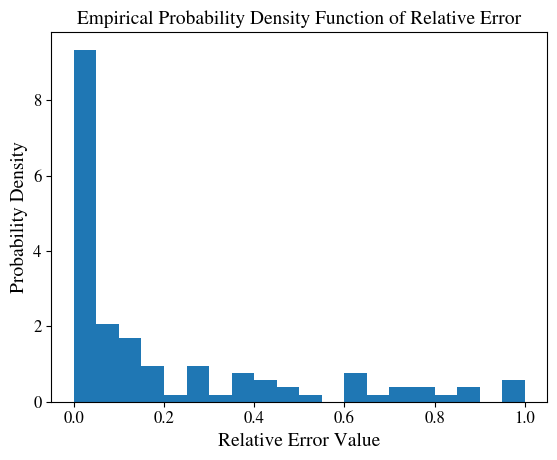

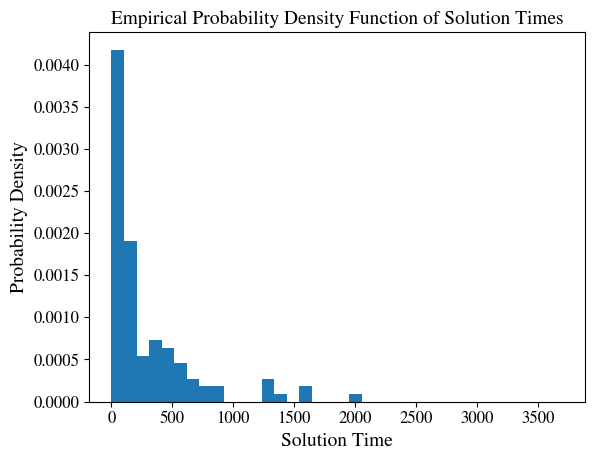

In [11]:
import matplotlib.pyplot as plt  # type: ignore

plt.hist(relative_errors, bins=20, range=(0, 1), density=True,)# cumulative=True)# edgecolor="black")
plt.xlabel("Relative Error Value")
plt.ylabel("Probability Density")
plt.title("Empirical Probability Density Function of Relative Error")
plt.show()


plt.hist(optimal_solution_times[0:num_of_scenarios], bins=36, range=(0, 3700), density=True,)# cumulative=True)# edgecolor="black")
plt.xlabel("Solution Time")
plt.ylabel("Probability Density")
plt.title("Empirical Probability Density Function of Solution Times")
plt.show()

### Create Visualization of an Episode with Network, Optimal Solution, and Agent Solution

#### Code

In [26]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import display
import contextily as cx

# Note: For the interactive plotter to work, you must enable the widget backend.
# Run `%matplotlib widget` in a separate cell or uncomment the line below.
# %matplotlib widget

def plot_network_with_edge_annotations(nodes, edges, obs, env, 
                                     all_optimal_interdiction_edges, episode,
                                     title="Network with Edge Characteristics",
                                     figsize=(14, 8), optimal_edges=None,
                                     use_map_background=False,
                                     map_crs='EPSG:3857', 
                                     map_source=None,
                                     node_size=300,
                                     show_costs=True,
                                     show_min_cut=False,
                                     show_flows=True):
    """
    Plot network with edge widths based on capacity and annotations for costs/probabilities.
    """
    import copy
    
    # Coordinate Conversion: Lat/Lon (4326) -> Web Mercator (3857)
    pos_map = {}
    if use_map_background and map_crs == 'EPSG:3857':
        try:
            from pyproj import Transformer
            transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
            for nid, n in nodes.items():
                pos_map[nid] = transformer.transform(n.xpos, n.ypos)
        except ImportError:
            print("Warning: pyproj not installed. Falling back to Lat/Lon coordinates (tiles may be warped).")
            pos_map = {nid: (n.xpos, n.ypos) for nid, n in nodes.items()}
            map_crs = 'EPSG:4326'
    else:
        pos_map = {nid: (n.xpos, n.ypos) for nid, n in nodes.items()}

    # Extract edge characteristics
    edge_capacity = obs['edge_capacity']
    edge_costs = obs['edge_costs']
    edge_interdiction_probability = obs['edge_interdiction_probability']
    budget = obs['budget'][0]

    # Get interdictable edges list (in order)
    interdictable_edges_list = list(env.both_edges)
    
    # Get optimal interdiction edges for this episode
    if optimal_edges == None:
        optimal_edges = all_optimal_interdiction_edges[episode] if episode < len(all_optimal_interdiction_edges) else set()

    # --- MIN CUT CALCULATION ---
    min_cut_edges = set()
    if show_min_cut:
        original_state_mc = None
        if hasattr(env, 'state'):
            original_state_mc = copy.deepcopy(env.state)
            
            # Sync env state with observation data
            for k, v in obs.items():
                env.state[k] = v
                
            try:
                # return_details=True returns objVal, actions_taken, cut_set, node_partitions
                ret = env.solve_min_cut_heuristic(return_details=True)
                if len(ret) >= 3:
                    min_cut_edges = set(ret[2])
            except Exception as e:
                print(f"Warning: Could not calculate min cut: {e}")
                
            # Restore state
            env.state = original_state_mc

    # --- MEAN FLOW CALCULATION ---
    # Calculate mean flows using the environment's internal method
    # Apply optimal interdictions to the environment state first
    mean_flows = {}
    try:
        current_strategy = env.attacker_strategy if hasattr(env, 'attacker_strategy') else "zero_sum"
        
        # Backup entire state
        original_state = None
        if hasattr(env, 'state'):
            original_state = env.state.copy()
            
            # Sync env state with observation data (capacities, objectives, etc.)
            for k, v in obs.items():
                env.state[k] = v
            
            # Apply optimal interdictions
            new_interdicted = np.zeros_like(env.state['edge_interdicted'])
            
            for edge in optimal_edges:
                if edge in env.edge_to_index:
                    idx = env.edge_to_index[edge]
                    new_interdicted[idx] = 1
                elif (edge[1], edge[0]) in env.edge_to_index:
                    idx = env.edge_to_index[(edge[1], edge[0])]
                    new_interdicted[idx] = 1
            
            env.state['edge_interdicted'] = new_interdicted
        
        # We need full flows to get flow values on edges
        obj, mean_flows_raw = env._calculate_stochastic_objective_and_flow(strategy_type=current_strategy, return_full_flows=True)
        
        # Convert to dictionary using scalar forward/reverse values per edge.
        if isinstance(mean_flows_raw, (np.ndarray, list, tuple)):
            flow_array = np.asarray(mean_flows_raw)
            flow_dict = {}
            if hasattr(env, 'edge_to_index'):
                if flow_array.ndim == 2 and flow_array.shape[1] == 2:
                    for edge, idx in env.edge_to_index.items():
                        if idx < flow_array.shape[0]:
                            flow_dict[edge] = float(flow_array[idx, 0])
                            flow_dict[(edge[1], edge[0])] = float(flow_array[idx, 1])
                else:
                    for edge, idx in env.edge_to_index.items():
                        if idx < flow_array.size:
                            value = np.asarray(flow_array[idx]).reshape(-1)
                            if value.size:
                                flow_dict[edge] = float(value[0])
            mean_flows = flow_dict
        else:
            mean_flows = mean_flows_raw

        print("Objective: ", obj)
        
        # Restore state
        if original_state is not None:
            env.state = original_state
            
    except Exception as e:
        print(f"Warning: Could not calculate mean flows: {e}")
        try:
             if 'original_interdicted' in locals() and original_interdicted is not None:
                env.state['edge_interdicted'] = original_interdicted
        except:
            pass
        mean_flows = {}
    
    # Identify strategies
    canalize_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "canalize" and 
        hasattr(env, 'state') and 'canalize_objective' in env.state):
        for i, edge_id in enumerate(interdictable_edges_list):
            if (i < len(env.state['canalize_objective']) and env.state['canalize_objective'][i] == 1):
                canalize_target_edges.add(edge_id)
    
    isolate_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "isolate" and 
        hasattr(env, 'state') and 'isolate_objective' in env.state):
        for i, edge_id in enumerate(interdictable_edges_list):
            if (i < len(env.state['isolate_objective']) and env.state['isolate_objective'][i] == 1):
                isolate_target_edges.add(edge_id)
    
    divert_to_target_edges = set()
    divert_from_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "divert" and hasattr(env, 'state')):
        if 'divert_to_objective' in env.state:
            for i, edge_id in enumerate(list(env.both_edges)):
                 if i < len(env.state['divert_to_objective']) and env.state['divert_to_objective'][i] == 1: divert_to_target_edges.add(edge_id)
        if 'divert_from_objective' in env.state:
             for i, edge_id in enumerate(list(env.both_edges)):
                 if i < len(env.state['divert_from_objective']) and env.state['divert_from_objective'][i] == 1: divert_from_target_edges.add(edge_id)

    divert_shared_edges = divert_to_target_edges.intersection(divert_from_target_edges)
    divert_to_target_edges -= divert_shared_edges
    divert_from_target_edges -= divert_shared_edges
    
    # Create Graph
    G = nx.Graph()
    source_nodes, sink_nodes = set(), set()
    for node_id, node_obj in nodes.items():
        if node_obj.node_type == 'source': source_nodes.add(node_id)
        elif node_obj.node_type == 'sink': sink_nodes.add(node_id)
    
    nodes_to_display = {}
    for node_id, node_obj in nodes.items():
        if node_obj.node_type not in ['source', 'sink']:
            G.add_node(node_id, pos=pos_map[node_id], node_type=node_obj.node_type)
            nodes_to_display[node_id] = node_obj
            
    nodes_connected_to_source, nodes_connected_to_sink = set(), set()
    for edge_id, edge_obj in edges.items():
        o, d = edge_id
        if o in source_nodes and d in nodes_to_display: nodes_connected_to_source.add(d)
        elif d in sink_nodes and o in nodes_to_display: nodes_connected_to_sink.add(o)

    edge_capacity_map = {eid: edge_capacity[i] for i, eid in enumerate(interdictable_edges_list)}
    edge_costs_map = {eid: edge_costs[i] for i, eid in enumerate(interdictable_edges_list)}
    edge_prob_map = {eid: edge_interdiction_probability[i] for i, eid in enumerate(interdictable_edges_list)}
    
    for edge_id, edge_obj in edges.items():
        o, d = edge_id
        if o in nodes_to_display and d in nodes_to_display:
            G.add_edge(o, d,
                       interdictable=edge_obj.interdictable,
                       capacity=edge_capacity_map.get(edge_id, 1.0),
                       cost=edge_costs_map.get(edge_id, 0.0),
                       probability=edge_prob_map.get(edge_id, 0.0))
    
    # Use fig, ax for better control
    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.get_node_attributes(G, 'pos')
    type_color_map = {'source_connected': '#ADB94C', 'intermediate': '#7BB6D0', 'sink_connected': '#E0B410'}
    
    # Draw Nodes
    
    # -- MODIFICATION START: Draw Isolated Nodes (Strategy 'isolate') --
    isolated_nodes_to_highlight = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "isolate" and isolate_target_edges):
        for u, v in isolate_target_edges:
            # Check sink connection in either direction (though environment uses incoming to sink)
            if v in nodes_connected_to_sink or v in nodes_to_display and nodes_to_display[v].node_type == 'sink': 
                 pass
            if v in sink_nodes: 
                 if v in nodes_to_display: isolated_nodes_to_highlight.add(v)
            elif u in sink_nodes:
                 if u in nodes_to_display: isolated_nodes_to_highlight.add(u)
            
            if u in nodes_connected_to_sink: isolated_nodes_to_highlight.add(u)
            if v in nodes_connected_to_sink: isolated_nodes_to_highlight.add(v)

    if isolated_nodes_to_highlight:
         nx.draw_networkx_nodes(G, pos, nodelist=list(isolated_nodes_to_highlight), 
                                node_color='red', node_size=node_size*3.0, alpha=0.5, 
                                ax=ax, label='Isolated Sink')
    # -- MODIFICATION END --
    
    for nlist, color in [([n for n in G.nodes if n in nodes_connected_to_source], 'source_connected'),
                         ([n for n in G.nodes if n in nodes_connected_to_sink], 'sink_connected'),
                         ([n for n in G.nodes if n not in nodes_connected_to_source and n not in nodes_connected_to_sink], 'intermediate')]:
        if nlist:
            nx.draw_networkx_nodes(G, pos, nodelist=nlist, node_color=type_color_map[color], node_size=node_size, edgecolors='black', linewidths=1, ax=ax)
            
    # Draw Edges
    interdictable = [(u, v) for u, v, d in G.edges(data=True) if d['interdictable']]
    non_interdictable = [(u, v) for u, v, d in G.edges(data=True) if not d['interdictable']]
    
    strategy_edges = set()
    special_groups = []
    
    if show_min_cut:
        min_cut_nodes = set()
        for u, v in min_cut_edges:
            min_cut_nodes.add(u)
            min_cut_nodes.add(v)
            
        adj_min_cut_edges = set()
        for u, v in G.edges():
            if (u, v) in min_cut_edges or (v, u) in min_cut_edges:
                continue
            if u in min_cut_nodes or v in min_cut_nodes:
                adj_min_cut_edges.add((u, v))
                
        G_no_cut = G.copy()
        for u, v in min_cut_edges:
            if G_no_cut.has_edge(u, v): G_no_cut.remove_edge(u, v)
            if G_no_cut.has_edge(v, u): G_no_cut.remove_edge(v, u)
            
        source_side_nodes = set()
        for start in nodes_connected_to_source:
            if start in G_no_cut:
                source_side_nodes.update(nx.node_connected_component(G_no_cut, start))
                
        sink_side_nodes = set()
        for start in nodes_connected_to_sink:
            if start in G_no_cut:
                sink_side_nodes.update(nx.node_connected_component(G_no_cut, start))
                
        source_side_edges = set()
        sink_side_edges = set()
        for u, v in G.edges():
            if (u, v) in min_cut_edges or (v, u) in min_cut_edges:
                continue
            if (u, v) in adj_min_cut_edges or (v, u) in adj_min_cut_edges:
                continue
            if u in source_side_nodes or v in source_side_nodes:
                source_side_edges.add((u, v))
            elif u in sink_side_nodes or v in sink_side_nodes:
                sink_side_edges.add((u, v))
                
        special_groups.extend([
            (sink_side_edges, '#4472C4'),
            (source_side_edges, '#5B9BD5'),
            (adj_min_cut_edges, '#ED7D31'),
            (min_cut_edges, '#FFC000')
        ])

    special_groups.extend([
        (canalize_target_edges, 'limegreen'),
        (divert_to_target_edges, 'limegreen'),
        (divert_from_target_edges, 'red'),
        (divert_shared_edges, 'blue')
    ])
    
    # Helper functions
    min_c, max_c = 30, 60
    def get_w(cap): return (7 + 7*((cap-min_c)/(max_c-min_c))) if max_c > min_c else 4.0
    def get_w_spec(cap): return (4 + 10*((cap-min_c)/(max_c-min_c))) if max_c > min_c else 4.0
    
    # Draw Special Edges
    for target_set, color in special_groups:
        if target_set:
            current = [(u,v) for u,v in interdictable if (u,v) in target_set or (v,u) in target_set]
            strategy_edges.update(current)
            if current:
                w = [get_w_spec(G[u][v]['capacity']) for u,v in current]
                a = [1.0 - 0.8*G[u][v]['probability'] for u,v in current]
                for i, (u,v) in enumerate(current):
                    nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i], edge_color='black', alpha=a[i], ax=ax)
                    nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i]-3, edge_color=color, alpha=1, ax=ax)

    # Draw Regular Edges
    regular = [(u,v) for u,v in interdictable if (u,v) not in strategy_edges and (v,u) not in strategy_edges]
    if regular:
        w = [get_w(G[u][v]['capacity']) for u,v in regular]
        a = [1.0 - 0.8*G[u][v]['probability'] for u,v in regular]
        for i, (u,v) in enumerate(regular):
            nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i], edge_color='black', alpha=a[i], ax=ax)
            nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i]-3, edge_color='white', alpha=1, ax=ax)

    if non_interdictable:
        nx.draw_networkx_edges(G, pos, edgelist=non_interdictable, width=2, edge_color='gray', alpha=0.5, ax=ax)

    # Draw Mean Flows
    if show_flows and mean_flows:
        G_dir = nx.DiGraph()
        for u in G.nodes():
            G_dir.add_node(u)
            
        for u, v in G.edges():
            G_dir.add_edge(u, v)
            G_dir.add_edge(v, u)

        for u, v in G.edges():
            flow_uv = mean_flows.get((u, v), 0)
            flow_vu = mean_flows.get((v, u), 0)
            
            capacity = G[u][v]['capacity']
            is_special = (u,v) in strategy_edges or (v,u) in strategy_edges
            outer_w = get_w_spec(capacity) if is_special else get_w(capacity)
            inner_w = max(0.5, outer_w - 3)
            
            # Flow from u to v
            if flow_uv > 0.01:
                flow_w_uv = min(inner_w, inner_w * (flow_uv/capacity)) if capacity > 0 else 0
                if flow_w_uv > 0.1:
                    # connectionstyle arcs ensure multiple flows don't overlap entirely
                    conn_style = "arc3,rad=0.05" if flow_vu > 0.01 else "arc3,rad=0.0"
                    nx.draw_networkx_edges(G_dir, pos, edgelist=[(u,v)], width=flow_w_uv, edge_color='blue', alpha=0.8, ax=ax, arrows=True, arrowsize=15, arrowstyle='-|>', connectionstyle=conn_style)
            
            # Flow from v to u
            if flow_vu > 0.01:
                flow_w_vu = min(inner_w, inner_w * (flow_vu/capacity)) if capacity > 0 else 0
                if flow_w_vu > 0.1:
                    conn_style = "arc3,rad=0.05" if flow_uv > 0.01 else "arc3,rad=0.0"
                    nx.draw_networkx_edges(G_dir, pos, edgelist=[(v,u)], width=flow_w_vu, edge_color='skyblue', alpha=0.8, ax=ax, arrows=True, arrowsize=15, arrowstyle='-|>', connectionstyle=conn_style)

    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
    
    # Cost Labels
    if show_costs:
        for u, v, d in G.edges(data=True):
            if d['interdictable']:
                u_pos, v_pos = pos[u], pos[v]
                mid_x, mid_y = (u_pos[0]+v_pos[0])/2, (u_pos[1]+v_pos[1])/2
                dx, dy = v_pos[0]-u_pos[0], v_pos[1]-u_pos[1]
                L = np.sqrt(dx**2+dy**2)
                if L>0:
                    px, py = -dy/L, dx/L
                    ax.text(mid_x+0.1*px, mid_y+0.1*py, f"{int(d['cost'])}", fontsize=14, color='red', ha='center', va='center', fontweight='bold')


    # Optimal Markers
    x_c, y_c = [], []
    for edge_id in optimal_edges:
        if edge_id in G.edges():
            u, v = edge_id
            x_c.append((pos[u][0]+pos[v][0])/2)
            y_c.append((pos[u][1]+pos[v][1])/2)
    if x_c:
        ax.scatter(x_c, y_c, marker='x', s=400, c='red', linewidths=4, zorder=10)

    # Budget Label
    ax.text(0.98, 1.05, f'Budget: {int(budget)}', transform=ax.transAxes, fontsize=14, color='red', fontweight='bold', ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # Add Map Background if requested
    if use_map_background:
        try:
            import contextily as cx
            
            # Default to CartoDB Positron if no source provided
            if map_source is None:
                map_source = cx.providers.CartoDB.Positron
            
            # ADD BACKGROUND MAP
            cx.add_basemap(ax, 
                           crs=map_crs, 
                           source=map_source,
                           zoom='auto', 
                           alpha=0.9)

        except ImportError:
            print("Warning: contextily not installed, skipping map background.")

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.axis('off')
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, label='Interdictable'),
    ]
    if show_flows:
        legend_elements.append(Line2D([0], [0], color='blue', lw=4, alpha=0.8, label='Mean Flow (Forward)'))
        legend_elements.append(Line2D([0], [0], color='skyblue', lw=4, alpha=0.8, label='Mean Flow (Reverse)'))
    legend_elements.append(Line2D([0], [0], marker='x', color='red', mew=4, markersize=12, linestyle='None', label='Optimal Choice'))
    if show_min_cut:
        legend_elements.append(Line2D([0], [0], color='#FFB347', lw=4, alpha=1, label='Min Cut'))
        legend_elements.append(Line2D([0], [0], color='darkorange', lw=4, alpha=1, label='Adj to Min Cut'))
        legend_elements.append(Line2D([0], [0], color='lightblue', lw=4, alpha=1, label='Source Side'))
        legend_elements.append(Line2D([0], [0], color='darkblue', lw=4, alpha=1, label='Sink Side'))

    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(legend_elements))
    
    plt.tight_layout()
    plt.show()
    return G

#### Plot

0.0
Reference Flow: None
Optimal Interdictions: [(6, 11), (8, 13), (12, 13), (13, 14), (13, 18)]
Optimal Objective    : 17.32961109595333
Agent Interdictions  : [(5, 10), (6, 11), (7, 12), (8, 13), (13, 18)]
Agent Objective      : 20.214902730786143
Agent Rel. Error     : 0.1665
Objective:  -5.2882102090924015


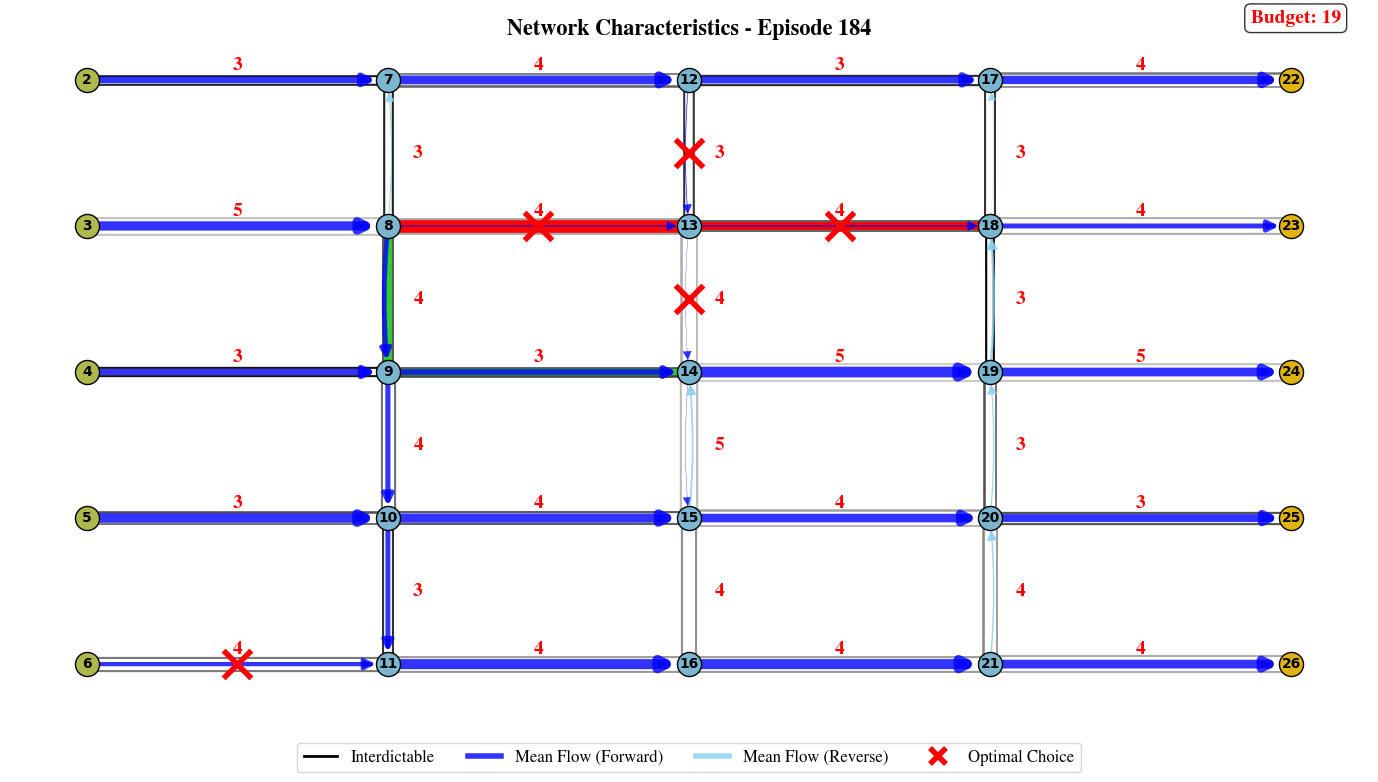

ENVIRONMENT STATE (Non-padded values only)
Actual number of edges in graph: 42

                               Budget Information                               
--------------------------------------------------------------------------------
Remaining / Reference Budget: 19 / 19

                             Edge State Information                             
--------------------------------------------------------------------------------
Index    Origin   Dest     Capacity     Cost     Int. Prob    Interdicted 
--------------------------------------------------------------------------------
0        1        2        45           4        0.00         0           
1        1        3        45           3        0.00         0           
2        1        4        45           3        0.00         0           
3        1        5        45           4        0.00         0           
4        1        6        45           3        0.00         0           
5        2        7       

In [30]:
# Usage with your code:
episode =184
obs, _ = env.load_network_from_state(seed=None, state=all_states[episode][0])
print(env.max_divert_objective)
#print(env.reference_start_flows)
#print(env.max_divert_objective)
print("Reference Flow:", env.reference_start_flow)
edge_capacity = obs['edge_capacity']
edge_costs = obs['edge_costs']
edge_interdiction_probability = obs['edge_interdiction_probability']

# Plot the network with optimal interdiction edges marked
if method_type == 'RL' and RL_classify:
    # Get heuristic actions for this specific episode again
    env_state = copy.deepcopy(all_states[episode][0])
    obs, _ = env.load_network_from_state(episode, copy.deepcopy(env_state))
    min_cut_objVal, min_cut_actions = env.solve_min_cut_heuristic()
    
    obs, _ = env.load_network_from_state(episode, copy.deepcopy(env_state))
    max_flow_objVal, max_flow_actions = env.solve_heuristic_interdiction()
    
    optimal_edges = {
        'optimal': all_optimal_interdiction_edges[episode],
        'rl': all_agent_actions[episode],
        'min_cut': min_cut_actions,
        'max_flow': max_flow_actions
    }
    
    print("\n--- Episode {} Results ---".format(episode))
    print(f"Optimal Interdictions : {all_optimal_interdiction_edges[episode]}")
    print(f"Optimal Objective     : {optimal_obj_vals[episode]}")
    
    print(f"\nRL Agent Interdictions: {all_agent_actions[episode]}")
    print(f"RL Agent Objective    : {agent_best_rewards[episode]}")
    print(f"RL Agent Rel. Error   : {relative_errors[episode]:.4f}")
    
    # Calculate dummy relative errors for heuristics strictly for print display
    ref_obj = reference_objs[episode]
    opt_obj = optimal_obj_vals[episode]
    
    def calc_rel_error(val, ref, opt, strat, empty_action=False):
        if empty_action and np.isnan(val): return 0.0
        if np.isnan(val): return 1.0 # Failed but took action
        if strat == "zero_sum":
            if ref == opt: return 0.0
            return max(0, val - opt) / (ref - opt)
        elif strat in ["canalize", "divert"]:
            denom = abs(ref - opt)
            if denom == 0: return 0.0
            return min(1.0, abs(val - opt) / denom)
        elif strat == "isolate":
            if ref == opt: return 0.0
            return max(0, ((ref - opt) - (ref - val)) / (ref - opt))
        return 0.0
        
    mc_err = calc_rel_error(min_cut_objVal, ref_obj, opt_obj, env_params['attacker_strategy'], len(min_cut_actions)==0)
    mf_err = calc_rel_error(max_flow_objVal, ref_obj, opt_obj, env_params['attacker_strategy'], len(max_flow_actions)==0)
    
    print(f"\nMin-Cut Interdictions : {min_cut_actions}")
    print(f"Min-Cut Objective     : {min_cut_objVal}")
    print(f"Min-Cut Rel. Error    : {mc_err:.4f}")
    
    print(f"\nMax-Flow Interdictions: {max_flow_actions}")
    print(f"Max-Flow Objective    : {max_flow_objVal}")
    print(f"Max-Flow Rel. Error   : {mf_err:.4f}")
    print("--------------------------\n")
    
else:
    optimal_edges =  all_optimal_interdiction_edges[episode]
    print(f"Optimal Interdictions: {all_optimal_interdiction_edges[episode]}")
    print(f"Optimal Objective    : {optimal_obj_vals[episode]}")
    print(f"Agent Interdictions  : {all_agent_actions[episode]}")
    print(f"Agent Objective      : {agent_best_rewards[episode]}")
    print(f"Agent Rel. Error     : {relative_errors[episode]:.4f}")

G = plot_network_with_edge_annotations(nodes, edges, obs, env, 
                                     all_optimal_interdiction_edges, episode,
                                     title=f"Network Characteristics - Episode {episode}", optimal_edges=optimal_edges)

env.render(indices = 41)

### Ukraine Map Plot

#### Code

In [32]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import display
import contextily as cx

# Note: For the interactive plotter to work, you must enable the widget backend.
# Run `%matplotlib widget` in a separate cell or uncomment the line below.
# %matplotlib widget

def plot_network_with_edge_annotations(nodes, edges, obs, env, 
                                     all_optimal_interdiction_edges, episode,
                                     title="Network with Edge Characteristics",
                                     figsize=(14, 8), optimal_edges=None,
                                     use_map_background=False,
                                     map_crs='EPSG:3857', 
                                     map_source=None,
                                     node_size=300,
                                     show_costs=True,
                                     show_min_cut=False,
                                     show_flows=True):
    """
    Plot network with edge widths based on capacity and annotations for costs/probabilities.
    """
    import copy
    
    # Coordinate Conversion: Lat/Lon (4326) -> Web Mercator (3857)
    pos_map = {}
    if use_map_background and map_crs == 'EPSG:3857':
        try:
            from pyproj import Transformer
            transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
            for nid, n in nodes.items():
                pos_map[nid] = transformer.transform(n.xpos, n.ypos)
        except ImportError:
            print("Warning: pyproj not installed. Falling back to Lat/Lon coordinates (tiles may be warped).")
            pos_map = {nid: (n.xpos, n.ypos) for nid, n in nodes.items()}
            map_crs = 'EPSG:4326'
    else:
        pos_map = {nid: (n.xpos, n.ypos) for nid, n in nodes.items()}

    # Extract edge characteristics
    edge_capacity = obs['edge_capacity']
    edge_costs = obs['edge_costs']
    edge_interdiction_probability = obs['edge_interdiction_probability']
    budget = obs['budget'][0]

    # Get interdictable edges list (in order)
    interdictable_edges_list = list(env.both_edges)
    
    # Get optimal interdiction edges for this episode
    if optimal_edges == None:
        optimal_edges = all_optimal_interdiction_edges[episode] if episode < len(all_optimal_interdiction_edges) else set()

    # --- MIN CUT CALCULATION ---
    min_cut_edges = set()
    if show_min_cut:
        original_state_mc = None
        if hasattr(env, 'state'):
            original_state_mc = copy.deepcopy(env.state)
            
            # Sync env state with observation data
            for k, v in obs.items():
                env.state[k] = v
                
            try:
                # return_details=True returns objVal, actions_taken, cut_set, node_partitions
                ret = env.solve_min_cut_heuristic(return_details=True)
                if len(ret) >= 3:
                    min_cut_edges = set(ret[2])
            except Exception as e:
                print(f"Warning: Could not calculate min cut: {e}")
                
            # Restore state
            env.state = original_state_mc

    # --- MEAN FLOW CALCULATION ---
    # Calculate mean flows using the environment's internal method
    # Apply optimal interdictions to the environment state first
    mean_flows = {}
    try:
        current_strategy = env.attacker_strategy if hasattr(env, 'attacker_strategy') else "zero_sum"
        
        # Backup entire state
        original_state = None
        if hasattr(env, 'state'):
            original_state = env.state.copy()
            
            # Sync env state with observation data (capacities, objectives, etc.)
            for k, v in obs.items():
                env.state[k] = v
            
            # Apply optimal interdictions
            new_interdicted = np.zeros_like(env.state['edge_interdicted'])
            
            for edge in optimal_edges:
                if edge in env.edge_to_index:
                    idx = env.edge_to_index[edge]
                    new_interdicted[idx] += 1
                elif (edge[1], edge[0]) in env.edge_to_index:
                    idx = env.edge_to_index[(edge[1], edge[0])]
                    new_interdicted[idx] += 1
            
            env.state['edge_interdicted'] = new_interdicted
        
        # We need full flows to get flow values on edges
        obj, mean_flows_raw = env._calculate_stochastic_objective_and_flow(strategy_type=current_strategy, return_full_flows=True)
        
        # Convert to dictionary considering the new dimension shapes [forward, reverse]
        if isinstance(mean_flows_raw, np.ndarray) or isinstance(mean_flows_raw, list):
            flow_dict = {}
            if hasattr(env, 'edge_to_index'):
                for edge, idx in env.edge_to_index.items():
                    if isinstance(mean_flows_raw, np.ndarray) and mean_flows_raw.ndim == 2 and mean_flows_raw.shape[1] == 2:
                        flow_dict[edge] = float(mean_flows_raw[idx, 0])
                        re = (edge[1], edge[0])
                        flow_dict[re] = float(mean_flows_raw[idx, 1])
                    else:
                        if idx < len(mean_flows_raw):
                            flow_dict[edge] = float(mean_flows_raw[idx])
            mean_flows = flow_dict
        else:
            mean_flows = mean_flows_raw

        print("Objective: ", obj)
        
        # Restore state
        if original_state is not None:
            env.state = original_state
            
    except Exception as e:
        print(f"Warning: Could not calculate mean flows: {e}")
        try:
             if 'original_interdicted' in locals() and original_interdicted is not None:
                env.state['edge_interdicted'] = original_interdicted
        except:
            pass
        mean_flows = {}
    
    # Identify strategies
    canalize_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "canalize" and 
        hasattr(env, 'state') and 'canalize_objective' in env.state):
        for i, edge_id in enumerate(interdictable_edges_list):
            if (i < len(env.state['canalize_objective']) and env.state['canalize_objective'][i] == 1):
                canalize_target_edges.add(edge_id)
    
    isolate_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "isolate" and 
        hasattr(env, 'state') and 'isolate_objective' in env.state):
        for i, edge_id in enumerate(interdictable_edges_list):
            if (i < len(env.state['isolate_objective']) and env.state['isolate_objective'][i] == 1):
                isolate_target_edges.add(edge_id)
    
    divert_to_target_edges = set()
    divert_from_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "divert" and hasattr(env, 'state')):
        if 'divert_to_objective' in env.state:
            for i, edge_id in enumerate(list(env.both_edges)):
                 if i < len(env.state['divert_to_objective']) and env.state['divert_to_objective'][i] == 1: divert_to_target_edges.add(edge_id)
        if 'divert_from_objective' in env.state:
             for i, edge_id in enumerate(list(env.both_edges)):
                 if i < len(env.state['divert_from_objective']) and env.state['divert_from_objective'][i] == 1: divert_from_target_edges.add(edge_id)

    divert_shared_edges = divert_to_target_edges.intersection(divert_from_target_edges)
    divert_to_target_edges -= divert_shared_edges
    divert_from_target_edges -= divert_shared_edges
    
    # Create Graph
    G = nx.Graph()
    source_nodes, sink_nodes = set(), set()
    for node_id, node_obj in nodes.items():
        if node_obj.node_type == 'source': source_nodes.add(node_id)
        elif node_obj.node_type == 'sink': sink_nodes.add(node_id)
    
    nodes_to_display = {}
    for node_id, node_obj in nodes.items():
        if node_obj.node_type not in ['source', 'sink']:
            G.add_node(node_id, pos=pos_map[node_id], node_type=node_obj.node_type)
            nodes_to_display[node_id] = node_obj
            
    nodes_connected_to_source, nodes_connected_to_sink = set(), set()
    for edge_id, edge_obj in edges.items():
        o, d = edge_id
        if o in source_nodes and d in nodes_to_display: nodes_connected_to_source.add(d)
        elif d in sink_nodes and o in nodes_to_display: nodes_connected_to_sink.add(o)

    edge_capacity_map = {eid: edge_capacity[i] for i, eid in enumerate(interdictable_edges_list)}
    edge_costs_map = {eid: edge_costs[i] for i, eid in enumerate(interdictable_edges_list)}
    edge_prob_map = {eid: edge_interdiction_probability[i] for i, eid in enumerate(interdictable_edges_list)}
    
    for edge_id, edge_obj in edges.items():
        o, d = edge_id
        if o in nodes_to_display and d in nodes_to_display:
            G.add_edge(o, d,
                       interdictable=edge_obj.interdictable,
                       capacity=edge_capacity_map.get(edge_id, 1.0),
                       cost=edge_costs_map.get(edge_id, 0.0),
                       probability=edge_prob_map.get(edge_id, 0.0))
    
    # Use fig, ax for better control
    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.get_node_attributes(G, 'pos')
    type_color_map = {'source_connected': '#ADB94C', 'intermediate': '#7BB6D0', 'sink_connected': '#E0B410'}
    
    # Draw Nodes
    
    # -- MODIFICATION START: Draw Isolated Nodes (Strategy 'isolate') --
    isolated_nodes_to_highlight = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "isolate" and isolate_target_edges):
        for u, v in isolate_target_edges:
            # Check sink connection in either direction (though environment uses incoming to sink)
            if v in nodes_connected_to_sink or v in nodes_to_display and nodes_to_display[v].node_type == 'sink': 
                 pass
            if v in sink_nodes: 
                 if v in nodes_to_display: isolated_nodes_to_highlight.add(v)
            elif u in sink_nodes:
                 if u in nodes_to_display: isolated_nodes_to_highlight.add(u)
            
            if u in nodes_connected_to_sink: isolated_nodes_to_highlight.add(u)
            if v in nodes_connected_to_sink: isolated_nodes_to_highlight.add(v)

    if isolated_nodes_to_highlight:
         nx.draw_networkx_nodes(G, pos, nodelist=list(isolated_nodes_to_highlight), 
                                node_color='red', node_size=node_size*3.0, alpha=0.5, 
                                ax=ax, label='Isolated Sink')
    # -- MODIFICATION END --
    
    for nlist, color in [([n for n in G.nodes if n in nodes_connected_to_source], 'source_connected'),
                         ([n for n in G.nodes if n in nodes_connected_to_sink], 'sink_connected'),
                         ([n for n in G.nodes if n not in nodes_connected_to_source and n not in nodes_connected_to_sink], 'intermediate')]:
        if nlist:
            nx.draw_networkx_nodes(G, pos, nodelist=nlist, node_color=type_color_map[color], node_size=node_size, edgecolors='black', linewidths=1, ax=ax)
            
    # Draw Edges
    interdictable = [(u, v) for u, v, d in G.edges(data=True) if d['interdictable']]
    non_interdictable = [(u, v) for u, v, d in G.edges(data=True) if not d['interdictable']]
    
    strategy_edges = set()
    special_groups = []
    
    if show_min_cut:
        min_cut_nodes = set()
        for u, v in min_cut_edges:
            min_cut_nodes.add(u)
            min_cut_nodes.add(v)
            
        adj_min_cut_edges = set()
        for u, v in G.edges():
            if (u, v) in min_cut_edges or (v, u) in min_cut_edges:
                continue
            if u in min_cut_nodes or v in min_cut_nodes:
                adj_min_cut_edges.add((u, v))
                
        G_no_cut = G.copy()
        for u, v in min_cut_edges:
            if G_no_cut.has_edge(u, v): G_no_cut.remove_edge(u, v)
            if G_no_cut.has_edge(v, u): G_no_cut.remove_edge(v, u)
            
        source_side_nodes = set()
        for start in nodes_connected_to_source:
            if start in G_no_cut:
                source_side_nodes.update(nx.node_connected_component(G_no_cut, start))
                
        sink_side_nodes = set()
        for start in nodes_connected_to_sink:
            if start in G_no_cut:
                sink_side_nodes.update(nx.node_connected_component(G_no_cut, start))
                
        source_side_edges = set()
        sink_side_edges = set()
        for u, v in G.edges():
            if (u, v) in min_cut_edges or (v, u) in min_cut_edges:
                continue
            if (u, v) in adj_min_cut_edges or (v, u) in adj_min_cut_edges:
                continue
            if u in source_side_nodes or v in source_side_nodes:
                source_side_edges.add((u, v))
            elif u in sink_side_nodes or v in sink_side_nodes:
                sink_side_edges.add((u, v))
                
        special_groups.extend([
            (sink_side_edges, '#4472C4'),
            (source_side_edges, '#5B9BD5'),
            (adj_min_cut_edges, '#ED7D31'),
            (min_cut_edges, '#FFC000')
        ])

    special_groups.extend([
        (canalize_target_edges, 'limegreen'),
        (divert_to_target_edges, 'limegreen'),
        (divert_from_target_edges, 'red'),
        (divert_shared_edges, 'blue')
    ])
    
    # Helper functions
    min_c, max_c = 30, 60
    def get_w(cap): return (7 + 7*((cap-min_c)/(max_c-min_c))) if max_c > min_c else 4.0
    def get_w_spec(cap): return (4 + 10*((cap-min_c)/(max_c-min_c))) if max_c > min_c else 4.0
    
    # Draw Special Edges
    for target_set, color in special_groups:
        if target_set:
            current = [(u,v) for u,v in interdictable if (u,v) in target_set or (v,u) in target_set]
            strategy_edges.update(current)
            if current:
                w = [get_w_spec(G[u][v]['capacity']) for u,v in current]
                a = [1.0 - 0.8*G[u][v]['probability'] for u,v in current]
                for i, (u,v) in enumerate(current):
                    nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i], edge_color='black', alpha=a[i], ax=ax)
                    nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i]-3, edge_color=color, alpha=1, ax=ax)

    # Draw Regular Edges
    regular = [(u,v) for u,v in interdictable if (u,v) not in strategy_edges and (v,u) not in strategy_edges]
    if regular:
        w = [get_w(G[u][v]['capacity']) for u,v in regular]
        a = [1.0 - 0.8*G[u][v]['probability'] for u,v in regular]
        for i, (u,v) in enumerate(regular):
            nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i], edge_color='black', alpha=a[i], ax=ax)
            nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i]-3, edge_color='white', alpha=1, ax=ax)

    if non_interdictable:
        nx.draw_networkx_edges(G, pos, edgelist=non_interdictable, width=2, edge_color='gray', alpha=0.5, ax=ax)

    # Draw Mean Flows
    if show_flows and mean_flows:
        G_dir = nx.DiGraph()
        for u in G.nodes():
            G_dir.add_node(u)
            
        for u, v in G.edges():
            G_dir.add_edge(u, v)
            G_dir.add_edge(v, u)

        for u, v in G.edges():
            flow_uv = mean_flows.get((u, v), 0)
            flow_vu = mean_flows.get((v, u), 0)
            
            capacity = G[u][v]['capacity']
            is_special = (u,v) in strategy_edges or (v,u) in strategy_edges
            outer_w = get_w_spec(capacity) if is_special else get_w(capacity)
            inner_w = max(0.5, outer_w - 3)
            
            # Flow from u to v
            if flow_uv > 0.01:
                flow_w_uv = min(inner_w, inner_w * (flow_uv/capacity)) if capacity > 0 else 0
                if flow_w_uv > 0.1:
                    # connectionstyle arcs ensure multiple flows don't overlap entirely
                    conn_style = "arc3,rad=0.15" if flow_vu > 0.01 else "arc3,rad=0.0"
                    nx.draw_networkx_edges(G_dir, pos, edgelist=[(u,v)], width=flow_w_uv, edge_color='blue', alpha=0.8, ax=ax, arrows=True, arrowsize=15, arrowstyle='-|>', connectionstyle=conn_style)
            
            # Flow from v to u
            if flow_vu > 0.01:
                flow_w_vu = min(inner_w, inner_w * (flow_vu/capacity)) if capacity > 0 else 0
                if flow_w_vu > 0.1:
                    conn_style = "arc3,rad=0.15" if flow_uv > 0.01 else "arc3,rad=0.0"
                    nx.draw_networkx_edges(G_dir, pos, edgelist=[(v,u)], width=flow_w_vu, edge_color='skyblue', alpha=0.8, ax=ax, arrows=True, arrowsize=15, arrowstyle='-|>', connectionstyle=conn_style)

    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
    
    # Cost Labels
    if show_costs:
        for u, v, d in G.edges(data=True):
            if d['interdictable']:
                u_pos, v_pos = pos[u], pos[v]
                mid_x, mid_y = (u_pos[0]+v_pos[0])/2, (u_pos[1]+v_pos[1])/2
                dx, dy = v_pos[0]-u_pos[0], v_pos[1]-u_pos[1]
                L = np.sqrt(dx**2+dy**2)
                if L>0:
                    px, py = -dy/L, dx/L
                    ax.text(mid_x+0.1*px, mid_y+0.1*py, f"{int(d['cost'])}", fontsize=14, color='red', ha='center', va='center', fontweight='bold')


    # Optimal Markers
    x_c, y_c = [], []
    for edge_id in optimal_edges:
        if edge_id in G.edges():
            u, v = edge_id
            x_c.append((pos[u][0]+pos[v][0])/2)
            y_c.append((pos[u][1]+pos[v][1])/2)
    if x_c:
        ax.scatter(x_c, y_c, marker='x', s=400, c='red', linewidths=4, zorder=10)

    # Budget Label
    ax.text(0.98, 1.05, f'Budget: {int(budget)}', transform=ax.transAxes, fontsize=14, color='red', fontweight='bold', ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # Add Map Background if requested
    if use_map_background:
        try:
            import contextily as cx
            
            # Default to CartoDB Positron if no source provided
            if map_source is None:
                map_source = cx.providers.CartoDB.Positron
            
            # ADD BACKGROUND MAP
            cx.add_basemap(ax, 
                           crs=map_crs, 
                           source=map_source,
                           zoom='auto', 
                           alpha=0.9)

        except ImportError:
            print("Warning: contextily not installed, skipping map background.")

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.axis('off')
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, label='Interdictable'),
    ]
    if show_flows:
        legend_elements.append(Line2D([0], [0], color='blue', lw=4, alpha=0.8, label='Mean Flow (Forward)'))
        legend_elements.append(Line2D([0], [0], color='skyblue', lw=4, alpha=0.8, label='Mean Flow (Reverse)'))
    legend_elements.append(Line2D([0], [0], marker='x', color='red', mew=4, markersize=12, linestyle='None', label='Optimal Choice'))
    if show_min_cut:
        legend_elements.append(Line2D([0], [0], color='#FFB347', lw=4, alpha=1, label='Min Cut'))
        legend_elements.append(Line2D([0], [0], color='darkorange', lw=4, alpha=1, label='Adj to Min Cut'))
        legend_elements.append(Line2D([0], [0], color='lightblue', lw=4, alpha=1, label='Source Side'))
        legend_elements.append(Line2D([0], [0], color='darkblue', lw=4, alpha=1, label='Sink Side'))

    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(legend_elements))
    
    plt.tight_layout()
    plt.show()
    return G

#### Plot

In [ ]:
# Usage with your code:
episode = 0
obs, _ = env.load_network_from_state(seed=None, state=all_states[episode][0])
print(env.reference_start_flows)
edge_capacity = obs['edge_capacity']
edge_costs = obs['edge_costs']
edge_interdiction_probability = obs['edge_interdiction_probability']

# Plot the network with optimal interdiction edges marked
optimal_edges = None#[(17,22), (20, 21), (21, 58)] # [(10, 15), (12, 17), (18, 23)] #[(9, 10), (11, 16), (12, 17), (14, 15), (18, 23)] #None #[]
print("Optimal Interdictions: ", all_optimal_interdiction_edges[episode])
print("Agent Interdictions: ", all_agent_actions[episode])
G = plot_network_with_edge_annotations(nodes, edges, obs, env, 
                                     all_optimal_interdiction_edges, episode,
                                     title=f"Network Characteristics - Episode {episode}", 
                                     use_map_background=True,
                                     optimal_edges = optimal_edges,
                                     map_source=cx.providers.CartoDB.Voyager,
                                       node_size=225,
                                       show_costs = False,
                                       show_flows= False,
                                        show_min_cut=False
)

print(optimal_obj_vals[episode])
print(optimal_solution_times[episode], " sec")
env.render(indices = 41)